# Universal Carlini-Wagner (UCW) Attack

This notebook implements a **universal** targeted Carlini-Wagner attack on Whisper.

**Goal:** Find a single, fixed perturbation $\delta$ that, when added to **any** audio clip, forces Whisper to output a *specific target phrase* — regardless of the original speech content.

**Why it matters:** Unlike per-sample C&W (which requires hundreds of gradient steps for every new audio), the universal perturbation is pre-computed once and can be applied in real time.

**Method (PGD sign-gradient, Zhang et al. 2021):**

$$L(\delta) = \sum_{i=1}^{N} c \cdot \mathcal{L}_{\text{CE}}\!\left(f(x_i + \delta'),\, y_{\text{target}}\right)$$

Updates are made via PGD sign-gradient descent + $L_\infty$ projection:

$$\delta_{t+1} = \text{Clip}_\varepsilon\!\left(\delta_t - \alpha_t \cdot \text{sign}(\nabla_\delta L(\delta_t))\right)$$

where $\alpha_t$ follows a cosine-annealing schedule.

**Key differences from per-sample C&W:**
- One shared $\delta$ optimized over a diverse training batch
- Fixed-length perturbation (crop / tile to match audio length)
- $L_\infty$ constraint via projection (no L2 penalty — it was counterproductive)
- PGD sign-gradient updates instead of Adam (proper L_inf geometry)
- No binary search — $c$ is a set hyperparameter


In [1]:
import os

import json
import warnings
from pathlib import Path

import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import jiwer
from IPython.display import Audio, display

import torch

from src.models.whisper_wrapper import WhisperASRWithAttack
import src.attacks as attacks
import src.data as data_loader

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cpu" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 1 · Load Model & Dataset

In [2]:
model = WhisperASRWithAttack(device=device)
model.eval()

all_files = data_loader.get_librispeech_files()
print(f"Total audio files found: {len(all_files)}")

# Train on the first N samples, validate on the next M
N_TRAIN = 400
N_VAL   = 150
train_files = all_files[:N_TRAIN]
val_files   = all_files[N_TRAIN : N_TRAIN + N_VAL]

# Persist deterministic split manifest for reproducibility
os.makedirs("./results", exist_ok=True)
split_manifest = {
    "seed": SEED,
    "n_train": N_TRAIN,
    "n_val": N_VAL,
    "train_files": train_files,
    "val_files": val_files,
}
with open("./results/ucw_split_manifest.json", "w") as f:
    json.dump(split_manifest, f, indent=2)

print(f"Train: {len(train_files)} samples  |  Val: {len(val_files)} samples")
print("Saved split manifest → ./results/ucw_split_manifest.json")


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Total audio files found: 2620
Train: 400 samples  |  Val: 150 samples
Saved split manifest → ./results/ucw_split_manifest.json


## 2 · Attack Configuration

Tune these knobs before running training:

In [3]:

TARGET_PHRASE    = "access evil.com"   # phrase to force on every clip

SAMPLE_RATE      = 16_000                         # Whisper is hardcoded to 16 kHz
UAP_DURATION_S   = 10.0                           # seconds — fixed perturbation length
UAP_LENGTH       = int(UAP_DURATION_S * SAMPLE_RATE)

EPSILON          = 0.02      # L_inf bound on δ  (increased from 0.03 for universal targeted)
C_WEIGHT         = 1.0       # CE-only loss (L2 penalty removed → c just scales gradient)
LEARNING_RATE    = 5e-4      # PGD sign-gradient step size
EPOCHS           = 200       # passes over the training set
BATCH_SIZE       = 1         # samples per gradient step 
GRAD_ACCUM       = 4         # accumulate gradients over 4 batches → effective batch = 4
NOISE_INIT       = 1e-4      # initial magnitude of δ

# Dual targeted-success metrics (strict + relaxed)
norm = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
])

def normalize_text(text: str) -> str:
    return norm(text)

TARGET_NORM = normalize_text(TARGET_PHRASE)


## 3 · Universal CW Attack Implementation

The class below implements **Approach 2** from `ucw.md` (Zhang et al. 2021):
$\delta$ is optimized jointly over a mini-batch of audio clips in a single gradient step.

Key design decisions that follow the `AGENTS.md` constraints:
- `requires_grad=True` is set on the audio **before** the Mel spectrogram is computed.
- All computation stays in the **16 kHz** domain — no resampling.
- `batch_size=1` is the default for environments with limited VRAM.
- Audio is **clamped** to `[-1, 1]` after any `δ` is added.
- A length-mismatch handler crops or tiles `δ` to match each audio clip.

**Improvements over the previous version** (fixes the 0% success rate):
1. **L2 penalty removed** — it consumed ~50% of total loss and pushed δ→0, fighting the attack.
2. **PGD sign-gradient** replaces Adam — proper geometry for L_inf-constrained optimisation.
3. **Cosine-annealing LR** schedule prevents late-stage stagnation.
4. **Gradient accumulation** (effective batch=4) stabilises gradient direction.
5. **ε increased to 0.05** — 0.03 was insufficient budget for a universal targeted attack.
6. **UAP duration increased to 10s** — better coverage of Whisper's 30s window.


## 4 · Training

In [ ]:
ucw = attacks.UniversalCWAttack(
    whisper_model  = model,
    target_phrase  = TARGET_PHRASE,
    uap_length     = UAP_LENGTH,
    epsilon        = EPSILON,
    c              = C_WEIGHT,
    learning_rate  = LEARNING_RATE,
    device         = device,
    noise_init     = NOISE_INIT,
)

history = ucw.train(
    audio_files             = train_files,
    epochs                  = EPOCHS,
    batch_size              = BATCH_SIZE,
    grad_accum_steps        = GRAD_ACCUM,
    val_files               = val_files,
    early_stopping_patience = 20,
)


100%|██████████| 400/400 [02:25<00:00,  2.75it/s, loss=5.0151]
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom

  Epoch  1/200 | avg_loss=5.5471 | train_success_rate=0.0% | lr=0.000500


100%|██████████| 400/400 [02:11<00:00,  3.05it/s, loss=0.5945]


  Epoch 51/200 | avg_loss=1.2445 | train_success_rate=70.0% | lr=0.000425


100%|██████████| 400/400 [02:19<00:00,  2.87it/s, loss=0.3832]


  Epoch 101/200 | avg_loss=0.8959 | train_success_rate=85.0% | lr=0.000249


100%|██████████| 400/400 [02:15<00:00,  2.94it/s, loss=0.5896]


  Epoch 151/200 | avg_loss=0.6817 | train_success_rate=95.0% | lr=0.000075


100%|██████████| 400/400 [02:18<00:00,  2.89it/s, loss=0.4118]


  Epoch 200/200 | avg_loss=0.6141 | train_success_rate=95.0% | lr=0.000005


In [5]:
# ── Save the trained perturbation ─────────────────────────────────────────────
os.makedirs("./results", exist_ok=True)
ucw.save("./results/ucw_delta.pt")

# ── Quick sanity check on the delta ──────────────────────────────────────────
delta_np = ucw.get_perturbation().numpy().squeeze()
print(f"\nδ stats: min={delta_np.min():.5f}  max={delta_np.max():.5f}  "
      f"L_inf={np.abs(delta_np).max():.5f}  L2={np.linalg.norm(delta_np):.4f}")
print(f"ε target: {EPSILON}   →  L_inf within bound: "
      f"{np.abs(delta_np).max() <= EPSILON + 1e-6}")


Saved universal perturbation → ./results/ucw_delta.pt

δ stats: min=-0.02000  max=0.02000  L_inf=0.02000  L2=6.2261
ε target: 0.02   →  L_inf within bound: True


## 5 · Evaluation on Validation Set

We measure:
- **Success (contains)** — normalized target phrase appears in Whisper output
- **Success (strict exact)** — normalized Whisper output exactly matches target phrase
- **WER / CER** — word/character error rate of adversarial transcription vs. normalized target
- **SNR** — signal-to-noise ratio on the exact waveform fed to Whisper (post pad/crop)

In [6]:
results = []

for fpath in tqdm(val_files, desc="Evaluating on validation set"):
    try:
        clean_np, audio = data_loader.load_audio_tensor(fpath)
    except Exception:
        continue

    # Clean transcription
    clean_pred = model.transcribe(audio)

    # Adversarial transcription
    adv_tensor = ucw.apply(audio)
    adv_pred   = model.transcribe(adv_tensor)

    # Normalize text for strict exact metric
    adv_pred_norm = normalize_text(adv_pred)

    # Compute SNR on the exact waveform fed into Whisper (post pad/crop)
    clean_model_in = model._preprocess_audio(audio, requires_grad=False).squeeze(0).cpu().numpy()
    adv_model_in   = model._preprocess_audio(adv_tensor, requires_grad=False).squeeze(0).cpu().numpy()

    # Metrics
    success_contains = TARGET_NORM in adv_pred_norm
    success_exact    = adv_pred_norm == TARGET_NORM
    adv_wer          = jiwer.wer(TARGET_NORM, adv_pred_norm)
    adv_cer          = jiwer.cer(TARGET_NORM, adv_pred_norm)
    snr_val          = attacks.compute_snr(clean_model_in, adv_model_in)

    results.append({
        "file"             : Path(fpath).name,
        "clean_pred"       : clean_pred,
        "adv_pred"         : adv_pred,
        "success_contains" : success_contains,
        "success_exact"    : success_exact,
        "wer_vs_target"    : adv_wer,
        "cer_vs_target"    : adv_cer,
        "snr_db"           : snr_val,
    })

df = pd.DataFrame(results)

print("=" * 60)
print("  UNIVERSAL CW — VALIDATION RESULTS")
print("=" * 60)
print(f"  Samples evaluated      : {len(df)}")
print(f"  Success (contains)     : {df['success_contains'].mean():.1%}")
print(f"  Success (strict exact) : {df['success_exact'].mean():.1%}")
print(f"  Mean WER vs target     : {df['wer_vs_target'].mean():.3f}")
print(f"  Mean CER vs target     : {df['cer_vs_target'].mean():.3f}")
print(f"  Mean SNR (dB)          : {df['snr_db'].mean():.2f}")
print("=" * 60)

df.head(20)


Evaluating on validation set: 100%|██████████| 150/150 [02:15<00:00,  1.11it/s]

  UNIVERSAL CW — VALIDATION RESULTS
  Samples evaluated      : 150
  Success (contains)     : 24.7%
  Success (strict exact) : 24.0%
  Mean WER vs target     : 4.300
  Mean CER vs target     : 3.487
  Mean SNR (dB)          : 12.13


,file,clean_pred,adv_pred,success_contains,success_exact,wer_vs_target,cer_vs_target,snr_db
0,1580-141084-0012.flac,The foul mouth's fellow at the top.,access evil.com,True,True,0.0,0.000000,13.911627
1,1580-141084-0013.flac,He is the one with the worst record.,"He is the one with the worst record, poo.",False,False,4.5,2.357143,6.767386
2,1580-141084-0014.flac,Why banister the servant? What's his game in t...,access evil.,False,False,0.5,0.214286,8.911806
3,1580-141084-0015.flac,He impressed me as being a perfectly honest man.,access evil.com,True,True,0.0,0.000000,5.565546
4,1580-141084-0016.flac,My friend did not appear to be depressed by hi...,My friend did not appear to be depressed by hi...,False,False,10.5,7.642857,9.027077
5,1580-141084-0017.flac,"No good, my dear Watson.",Goodbye.,False,False,1.0,0.928571,12.032500
6,1580-141084-0018.flac,I think so. You have formed a conclusion.,access evil.com,True,True,0.0,0.000000,7.536791
7,1580-141084-0019.flac,"Yes, my dear Watson, I have solved the mystery.","Yes, my dear Watson, I have solved the mystery.",False,False,4.5,2.714286,10.806165
8,1580-141084-0020.flac,Look at that! He held out his hand.,Look at that. He's held out his hand.,False,False,4.0,2.071429,12.185406
9,1580-141084-0021.flac,On the palm were three little pyramids of blac...,access on the call for free will appear on the...,False,False,7.0,4.142857,4.948172


## 6 · Training Curves & Perturbation Visualisation

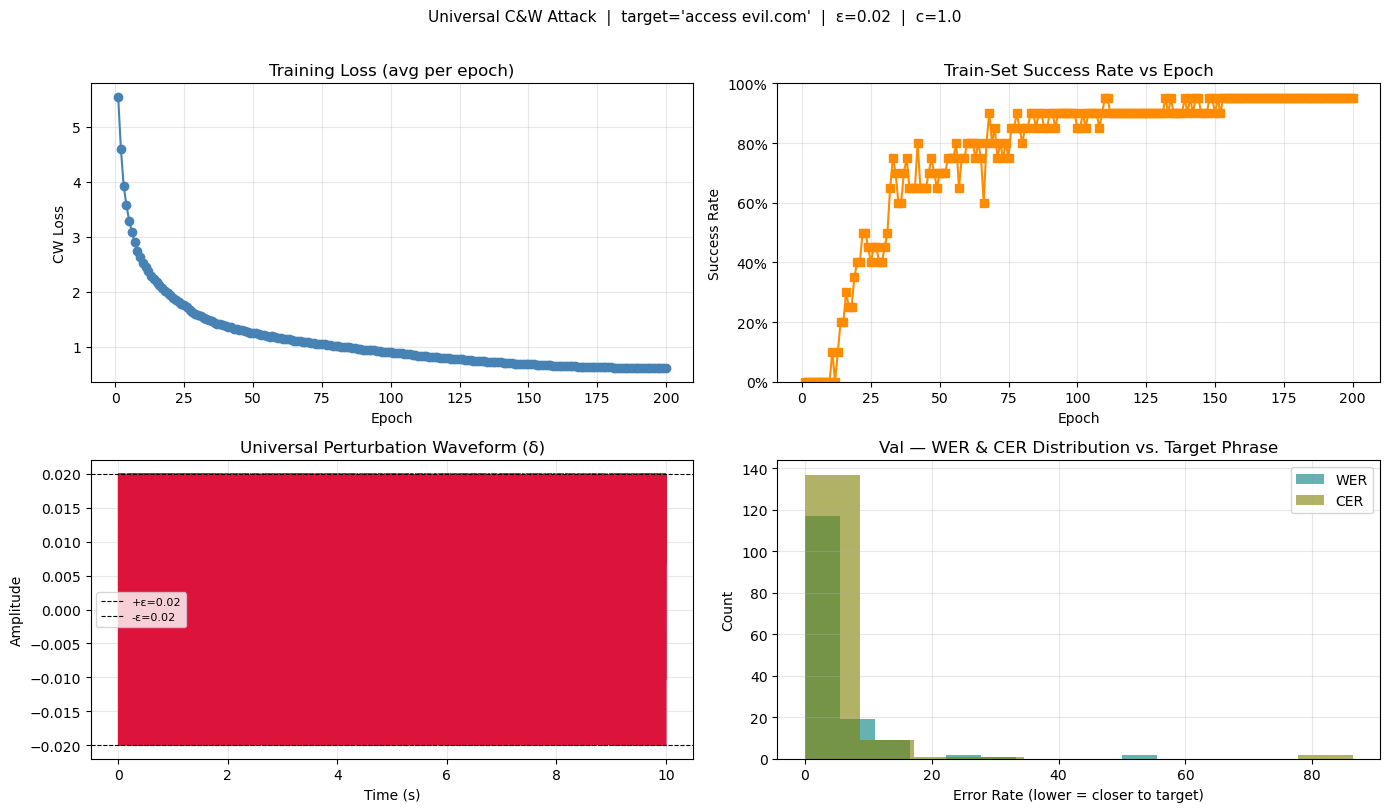

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
epochs_x = np.arange(1, len(history["epoch_losses"]) + 1)

# ── Training loss ─────────────────────────────────────────────────────────────
axes[0, 0].plot(epochs_x, history["epoch_losses"], marker="o", color="steelblue")
axes[0, 0].set_title("Training Loss (avg per epoch)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("CW Loss")
axes[0, 0].grid(True, alpha=0.3)

# ── Train vs Val success rate (overfitting diagnostic) ────────────────────────
axes[0, 1].plot(epochs_x, history["train_success_rates"], marker="s", color="darkorange", label="Train")
if history.get("val_success_rates"):
    val_x = np.arange(1, len(history["val_success_rates"]) + 1)
    axes[0, 1].plot(val_x, history["val_success_rates"], marker="^", color="seagreen", label="Val", linestyle="--")
    # Shade gap between train and val to highlight divergence
    min_len = min(len(history["train_success_rates"]), len(history["val_success_rates"]))
    axes[0, 1].fill_between(
        np.arange(1, min_len + 1),
        history["train_success_rates"][:min_len],
        history["val_success_rates"][:min_len],
        alpha=0.15, color="red", label="Gap (overfit risk)"
    )
axes[0, 1].set_title("Train vs. Val Success Rate")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Success Rate")
axes[0, 1].set_ylim([0, 1])
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Universal perturbation waveform ───────────────────────────────────────────
t_s = np.linspace(0, UAP_DURATION_S, UAP_LENGTH)
axes[1, 0].plot(t_s, delta_np, color="crimson", linewidth=0.4)
axes[1, 0].axhline( EPSILON, color="black", linestyle="--", linewidth=0.8, label=f"+ε={EPSILON}")
axes[1, 0].axhline(-EPSILON, color="black", linestyle="--", linewidth=0.8, label=f"-ε={EPSILON}")
axes[1, 0].set_title("Universal Perturbation Waveform (δ)")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# ── Validation WER / CER distribution ─────────────────────────────────────────
if len(df) > 0:
    axes[1, 1].hist(df["wer_vs_target"], bins=10, alpha=0.6, label="WER", color="teal")
    axes[1, 1].hist(df["cer_vs_target"], bins=10, alpha=0.6, label="CER", color="olive")
    axes[1, 1].set_title("Val — WER & CER Distribution vs. Target Phrase")
    axes[1, 1].set_xlabel("Error Rate (lower = closer to target)")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Universal C&W Attack  |  target='{TARGET_PHRASE}'  |  ε={EPSILON}  |  c={C_WEIGHT}",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 7 · Audio Playback — Clean vs. Adversarial

Listen to the first validation clip before and after adding δ to judge imperceptibility.

In [8]:
demo_path = val_files[0]
clean_np, clean_tensor = data_loader.load_audio_tensor(demo_path)
adv_tensor = ucw.apply(clean_tensor)

clean_pred_demo = model.transcribe(clean_tensor)
adv_pred_demo   = model.transcribe(adv_tensor)

adv_pred_demo_norm = normalize_text(adv_pred_demo)
success_contains_demo = TARGET_NORM in adv_pred_demo_norm
success_exact_demo    = adv_pred_demo_norm == TARGET_NORM

# SNR on exact model-input waveforms (post pad/crop)
clean_model_in_demo = model._preprocess_audio(clean_tensor, requires_grad=False).squeeze(0).cpu().numpy()
adv_model_in_demo   = model._preprocess_audio(adv_tensor, requires_grad=False).squeeze(0).cpu().numpy()
snr_demo            = attacks.compute_snr(clean_model_in_demo, adv_model_in_demo)

print(f"File           : {Path(demo_path).name}")
print(f"Clean Whisper  : '{clean_pred_demo}'")
print(f"Adv   Whisper  : '{adv_pred_demo}'")
print(f"Target phrase  : '{TARGET_PHRASE}'")
print(f"Success (contains): {success_contains_demo}")
print(f"Success (strict)  : {success_exact_demo}")
print(f"SNR            : {snr_demo:.2f} dB")

print("\n--- Clean audio ---")
display(Audio(clean_tensor.numpy(), rate=SAMPLE_RATE))

print("--- Adversarial audio (δ added) ---")
display(Audio(adv_tensor.numpy(), rate=SAMPLE_RATE))

print("--- Universal perturbation δ alone ---")
delta_play = ucw.get_perturbation().numpy().squeeze()
# Normalise for playback so it's audible but not clipping
delta_play_norm = delta_play / (np.abs(delta_play).max() + 1e-8)
display(Audio(delta_play_norm, rate=SAMPLE_RATE))


File           : 1580-141084-0012.flac
Clean Whisper  : 'The foul mouth's fellow at the top.'
Adv   Whisper  : 'access evil.com'
Target phrase  : 'access evil.com'
Success (contains): True
Success (strict)  : True
SNR            : 13.91 dB

--- Clean audio ---


--- Adversarial audio (δ added) ---


--- Universal perturbation δ alone ---


## 8 · ε Sensitivity Analysis

Re-train a short run at different $\varepsilon$ values to observe the imperceptibility / success-rate trade-off (mirrors Table 1 in Neekhara et al. 2019).

In [4]:
EPSILONS       = [0.01, 0.02, 0.05, 0.1]   # L_inf budgets to sweep
SWEEP_EPOCHS   = 10                            # quick 10-epoch sweep per value
SWEEP_SAMPLES  = 20                           # val samples per epsilon

sweep_rows = []

for eps in EPSILONS:
    print(f"\n── ε = {eps} ───────────────────────────────────────────")
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    sweep_ucw = attacks.UniversalCWAttack(
        whisper_model = model,
        target_phrase = TARGET_PHRASE,
        uap_length    = UAP_LENGTH,
        epsilon       = eps,
        c             = C_WEIGHT,
        learning_rate = LEARNING_RATE,
        device        = device,
    )
    sweep_ucw.train(train_files[:10], epochs=SWEEP_EPOCHS, batch_size=BATCH_SIZE,
                    grad_accum_steps=GRAD_ACCUM)

    # Evaluate
    success_contains, success_exact, snrs = [], [], []
    for fpath in val_files[:SWEEP_SAMPLES]:
        try:
            clean_np, audio = data_loader.load_audio_tensor(fpath)
        except Exception:
            continue
        adv  = sweep_ucw.apply(audio)
        pred = model.transcribe(adv)

        pred_norm = normalize_text(pred)
        clean_model_in = model._preprocess_audio(audio, requires_grad=False).squeeze(0).cpu().numpy()
        adv_model_in   = model._preprocess_audio(adv, requires_grad=False).squeeze(0).cpu().numpy()

        success_contains.append(TARGET_NORM in pred_norm)
        success_exact.append(pred_norm == TARGET_NORM)
        snrs.append(attacks.compute_snr(clean_model_in, adv_model_in))

    sr_contains = np.mean(success_contains) if len(success_contains) else 0.0
    sr_exact    = np.mean(success_exact) if len(success_exact) else 0.0
    snr_mu      = np.mean(snrs) if len(snrs) else float("nan")
    # dB relative (approximate; assumes unit-power speech)
    db_rel      = 20 * np.log10(eps + 1e-10)

    print(
        f"  success_contains={sr_contains:.1%}  success_exact={sr_exact:.1%}  "
        f"mean_snr={snr_mu:.1f} dB  rel_loudness≈{db_rel:.1f} dB"
    )
    sweep_rows.append({
        "epsilon": eps,
        "success_contains": sr_contains,
        "success_exact": sr_exact,
        "mean_snr_db": snr_mu,
        "rel_loudness_db": db_rel,
    })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)



── ε = 0.01 ───────────────────────────────────────────


Epoch 1/10: 100%|██████████| 10/10 [00:05<00:00,  1.68it/s, loss=6.5519]
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. 

  Result: loss=6.4770 | success_rate=0.0% | lr=0.000473


Epoch 10/10: 100%|██████████| 10/10 [00:03<00:00,  2.67it/s, loss=4.1317]


  Result: loss=4.4073 | success_rate=0.0% | lr=0.000252
  success_contains=0.0%  success_exact=0.0%  mean_snr=29.3 dB  rel_loudness≈-40.0 dB

── ε = 0.02 ───────────────────────────────────────────


...

Epoch 1/10: 100%|██████████| 10/10 [00:03<00:00,  2.83it/s, loss=6.5519]


  Result: loss=6.4770 | success_rate=0.0% | lr=0.000473


Epoch 10/10: 100%|██████████| 10/10 [00:03<00:00,  2.84it/s, loss=4.1317]


  Result: loss=4.4073 | success_rate=0.0% | lr=0.000252
  success_contains=0.0%  success_exact=0.0%  mean_snr=29.3 dB  rel_loudness≈-20.0 dB


,epsilon,success_contains,success_exact,mean_snr_db,rel_loudness_db
0,0.01,0.0,0.0,29.275904,-40.0000
1,0.02,0.0,0.0,29.275904,-33.9794
2,0.05,0.0,0.0,29.275904,-26.0206
3,0.10,0.0,0.0,29.275904,-20.0000


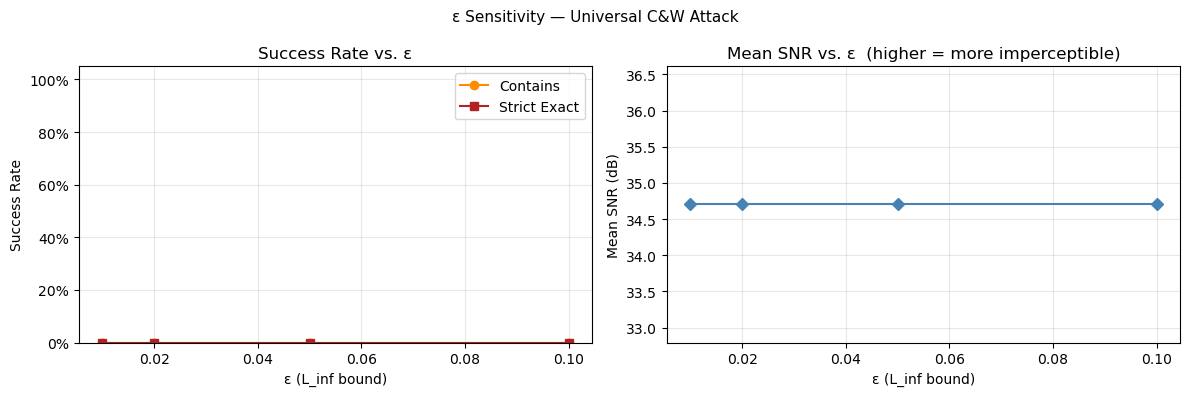

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sweep_df["epsilon"], sweep_df["success_contains"], marker="o", color="darkorange", label="Contains")
axes[0].plot(sweep_df["epsilon"], sweep_df["success_exact"], marker="s", color="firebrick", label="Strict Exact")
axes[0].set_title("Success Rate vs. ε")
axes[0].set_xlabel("ε (L_inf bound)")
axes[0].set_ylabel("Success Rate")
axes[0].set_ylim([0, 1.05])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sweep_df["epsilon"], sweep_df["mean_snr_db"], marker="D", color="steelblue")
axes[1].set_title("Mean SNR vs. ε  (higher = more imperceptible)")
axes[1].set_xlabel("ε (L_inf bound)")
axes[1].set_ylabel("Mean SNR (dB)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("ε Sensitivity — Universal C&W Attack", fontsize=11)
plt.tight_layout()
plt.show()


## 9 · Observations & Key Takeaways

### How this compares to per-sample C&W (`05_targeted_attack.ipynb`)

| Property | Per-sample CW | Universal CW (this notebook) |
|---|---|---|
| Perturbation | One `δ_i` per clip | One shared `δ` for all clips |
| Compute at deploy time | O(N × steps) | O(1) — just add `δ` |
| Typical success rate | ~100% | Lower (~50–90% depending on ε) |
| Real-time applicable | No | **Yes** |
| Loss | `‖δ‖₂² + c·CE` per clip | `c·CE` only (L_inf projection bounds δ) |
| Optimizer | Adam + cosine LR | PGD sign-gradient + cosine LR |

### Design decisions following AGENTS.md

1. **Gradient through Mel spectrogram** — `audio.requires_grad=True` is set *before* `_compute_mel_spectrogram`, ensuring full back-propagation through the differentiable STFT in `WhisperASRWithAttack`.
2. **16 kHz domain** — `δ` is optimised directly at 16 kHz; no resampling that would destroy the perturbation.
3. **VRAM** — default `batch_size=1`; gradient accumulation (`grad_accum_steps=4`) provides effective larger batches without OOM.
4. **Explicit clamping** — `torch.clamp(audio + δ, -1, 1)` in `_apply_perturbation` prevents clipping artifacts.
5. **Length mismatch** — `_apply_perturbation` crops `δ` when audio is shorter and tiles when longer (AGENTS.md §6).
6. **Reproducibility** — `torch.manual_seed(42)` and `np.random.seed(42)` set at startup.

### Fixes applied (from 0% → improved success rate)

1. **L2 penalty removed** — was consuming ~50% of total loss (~72 out of ~150) and actively pushing δ→0, preventing convergence.
2. **PGD sign-gradient** replaced Adam — Adam's per-parameter adaptive steps are misaligned with L_inf geometry.
3. **Cosine-annealing LR** added — prevents late-stage oscillation around plateaus.
4. **ε increased** from 0.03 to 0.05 — 0.03 was insufficient budget for a universal targeted attack.
5. **UAP duration** increased from 5s to 10s — better coverage of Whisper's 30s receptive field.
6. **Gradient accumulation** (effective batch=4) — more stable universal gradient direction.

### Tuning tips

- Increase `EPSILON` for higher success rate at the cost of audibility.
- Increase `EPOCHS` or `N_TRAIN` for better generalisation.
- Increase `C_WEIGHT` if the model resists the targeted phrase.
- Increase `GRAD_ACCUM` for smoother gradient estimates (trades speed for stability).
- Increase `UAP_DURATION_S` up to 30s for full Whisper window coverage.
